In [1]:
#Importar librerias 
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = kagglehub.dataset_download("msnbehdani/mock-dataset-of-second-hand-car-sales")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\pirom\.cache\kagglehub\datasets\msnbehdani\mock-dataset-of-second-hand-car-sales\versions\1


In [3]:
df=pd.read_csv(f'{path}\\car_sales_data.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         50000 non-null  str    
 1   Model                50000 non-null  str    
 2   Engine size          50000 non-null  float64
 3   Fuel type            50000 non-null  str    
 4   Year of manufacture  50000 non-null  int64  
 5   Mileage              50000 non-null  int64  
 6   Price                50000 non-null  int64  
dtypes: float64(1), int64(3), str(3)
memory usage: 3.4 MB


In [5]:
df.sample(5)

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
35997,Ford,Fiesta,1.4,Petrol,2013,84066,10436
29580,Toyota,Prius,1.4,Hybrid,2022,4711,55641
35779,Ford,Mondeo,1.4,Diesel,2014,33693,23259
8822,Ford,Fiesta,1.2,Petrol,2003,173929,2459
26281,Toyota,RAV4,2.0,Petrol,1992,120969,4148


In [6]:
df.duplicated().sum()

np.int64(12)

In [7]:
df.isna().sum()

Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64

In [8]:
df.drop_duplicates(inplace=True, ignore_index=False)

In [9]:
df.columns = (df.columns
                .str.replace(r'(?<=[a-z])(?=[A-Z])', '_', regex=True)
                .str.replace(r'[ -]', '_', regex=True)               
                .str.lower())
df.columns

Index(['manufacturer', 'model', 'engine_size', 'fuel_type',
       'year_of_manufacture', 'mileage', 'price'],
      dtype='str')

In [10]:
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    
    return df_clean

In [11]:
cols = ['price', 'mileage']
df = remove_outliers_iqr(df, cols)

In [12]:
df['year_of_manufacture'] = df['year_of_manufacture'].astype(int)

In [13]:
df['car_age'] = 2026 - df['year_of_manufacture']

In [14]:
df_groub_by_manufacturer=df.groupby(['manufacturer','fuel_type'])[['mileage','price']].mean().reset_index().round(2)
df_groub_by_manufacturer

,manufacturer,fuel_type,mileage,price
0,BMW,Diesel,121471.74,13589.78
1,BMW,Petrol,129940.46,14085.15
2,Ford,Diesel,111853.95,11908.42
3,Ford,Hybrid,113994.27,11508.35
4,Ford,Petrol,111587.21,9005.38
5,Porsche,Diesel,141209.60,14611.06
6,Porsche,Petrol,133916.52,15248.22
7,Toyota,Hybrid,116127.68,12525.90
8,Toyota,Petrol,112072.33,9772.31
9,VW,Diesel,114552.41,11195.98


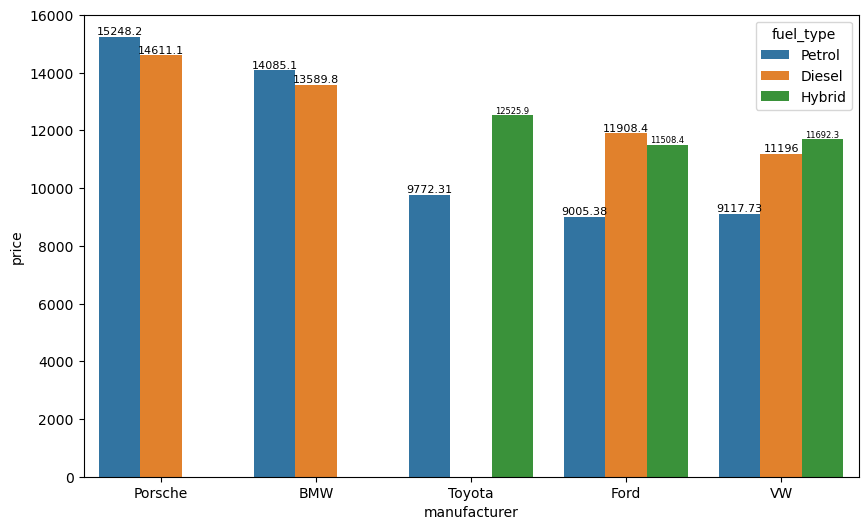

In [15]:
#se grafica
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="manufacturer", y="price",hue='fuel_type', data=df_groub_by_manufacturer.sort_values('price',ascending=False))
ax.bar_label(ax.containers[0], fontsize=8)
ax.bar_label(ax.containers[1], fontsize=8)
ax.bar_label(ax.containers[2], fontsize=6)
ax.set(xlabel='manufacturer', ylabel='price')
plt.show()

In [16]:
df_groub_by_engine=df.groupby(['engine_size'])[['price']].mean().reset_index().round(2)
df_groub_by_engine

,engine_size,price
0,1.0,8583.38
1,1.2,8180.17
2,1.4,10284.72
3,1.6,10959.59
4,1.8,12564.12
5,2.0,12206.45
6,2.2,13693.03
7,2.4,13582.73
8,2.6,15260.31
9,3.0,14435.08


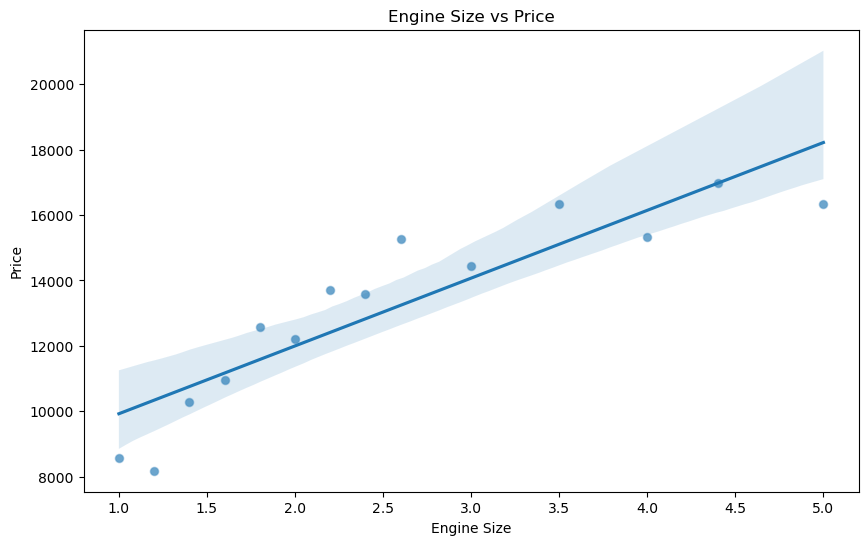

In [17]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_groub_by_engine, x="engine_size", y="price", alpha=0.5)
sns.regplot(data=df_groub_by_engine, x="engine_size", y="price", scatter_kws={"alpha":0.3})
plt.xlabel("Engine Size")
plt.ylabel("Price")
plt.title("Engine Size vs Price")
plt.show()

In [18]:
df_group_by_year=df[['mileage','price']]
df_group_by_year

,mileage,price
0,127300,3074
2,39190,24072
3,210814,1705
4,127869,4101
5,33603,29204
...,...,...
49993,120969,6654
49994,101634,10639
49996,105120,9430
49998,26468,23630


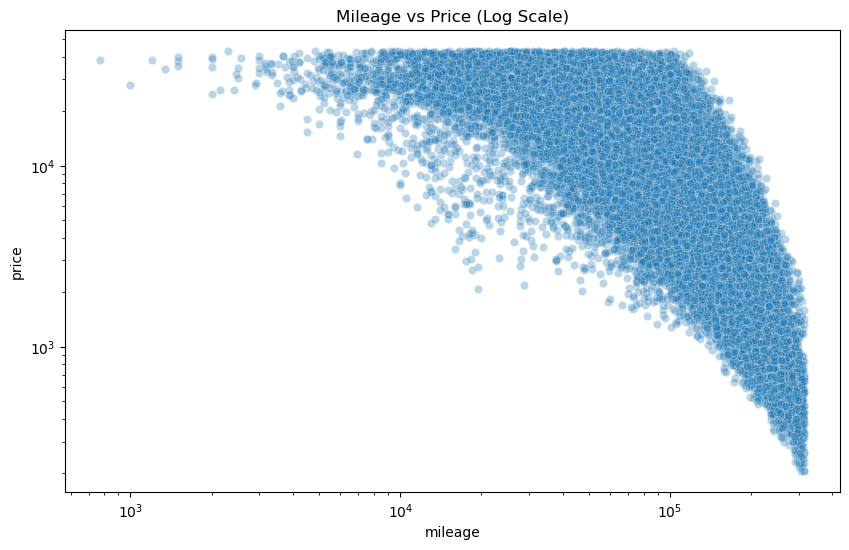

In [19]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_group_by_year, x="mileage", y="price", alpha=0.3)

plt.xscale("log")
plt.yscale("log")
plt.title("Mileage vs Price (Log Scale)")
plt.show()

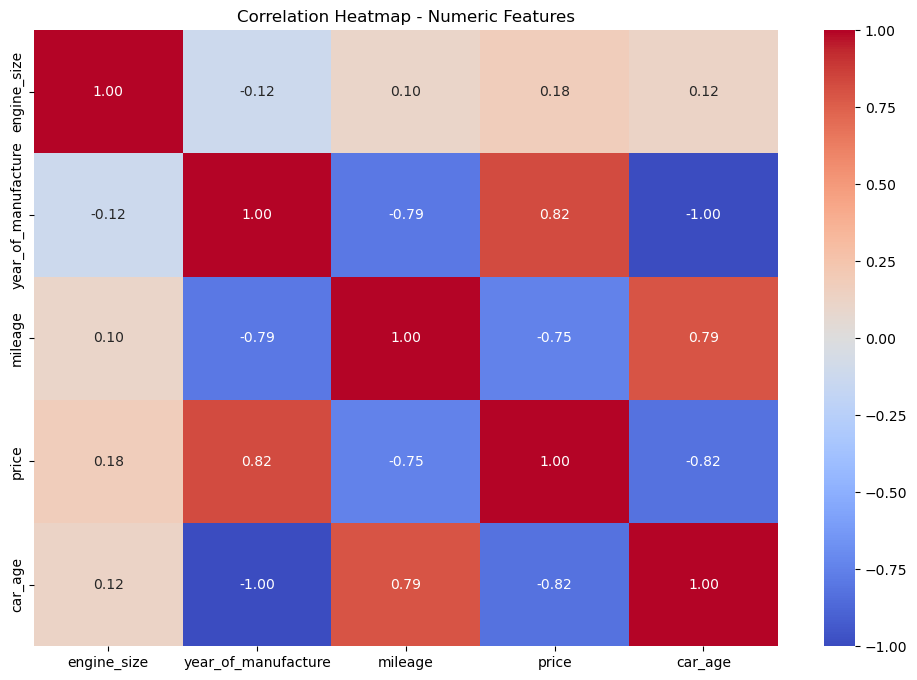

In [20]:
# Seleccionar solo columnas numéricas
df_numeric = df.select_dtypes(include=['int64', 'float64'])

# Matriz de correlación
corr_matrix = df_numeric.corr()

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap - Numeric Features")
plt.show()

C:\Users\pirom\AppData\Local\Temp\ipykernel_13072\2984347400.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object'])


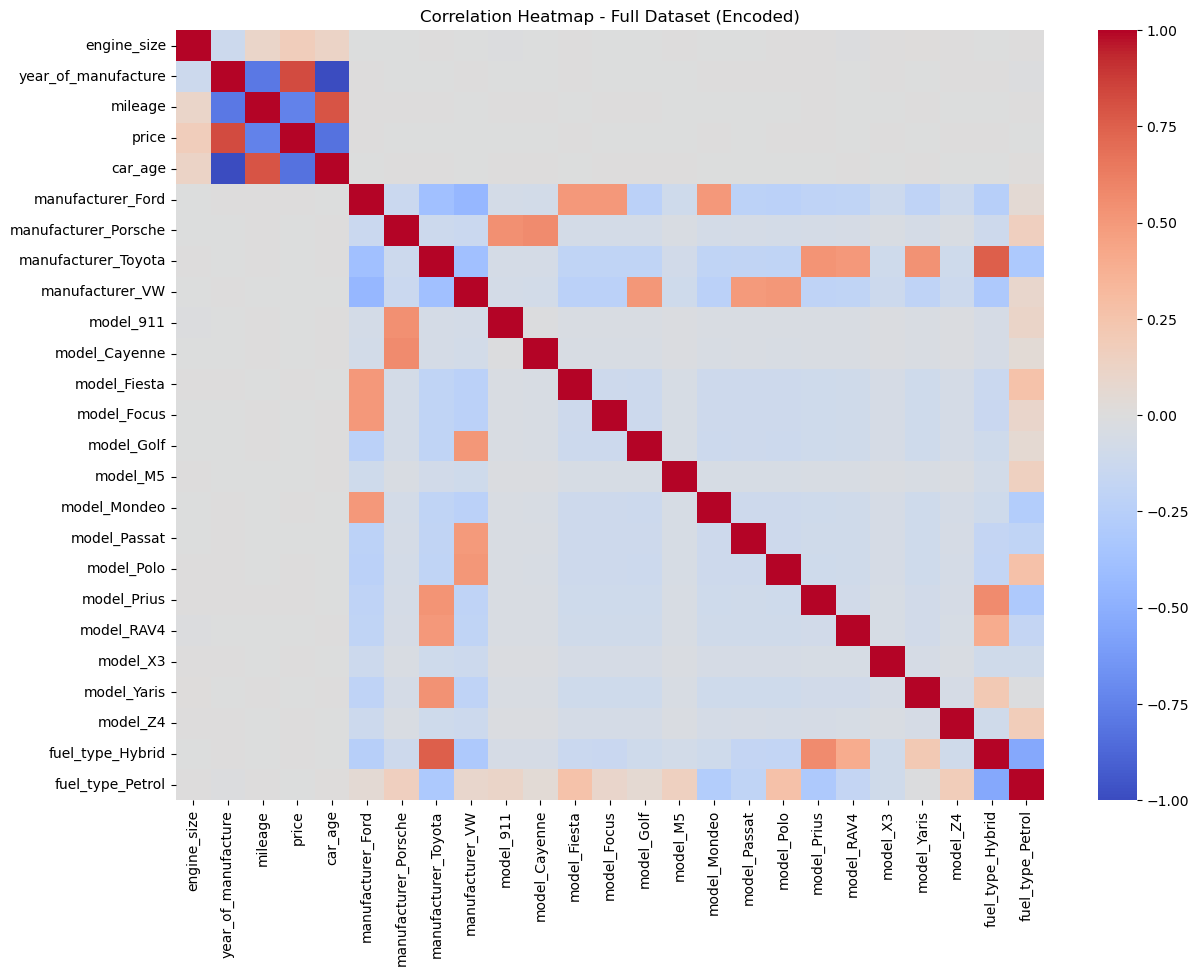

In [21]:
from sklearn.preprocessing import OneHotEncoder

# Separar columnas
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
categorical_cols = df.select_dtypes(include=['object'])

# One Hot Encoding
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded = encoder.fit_transform(categorical_cols)

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols.columns))

# Unir dataset
df_full = pd.concat([numeric_cols, encoded_df], axis=1)

# Correlación
corr_matrix = df_full.corr()

# Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Full Dataset (Encoded)")
plt.show()

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
df_full = df_full.dropna(subset=['price'])

X = df_full.drop('price', axis=1)
y = df_full['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:


model_rf = RandomForestRegressor()
model_rf.fit(X_train, y_train)

preds_rf = model_rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds_rf))
rmse = root_mean_squared_error(y_test, preds_rf)
print(f"RMSE: {rmse}")


print("R2:", r2_score(y_test, preds_rf))

MAE: 1724.3732310299547
RMSE: 2783.385363750759
R2: 0.9276495430222587


In [24]:
import xgboost as xgb
model_xgb = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    objective='reg:squarederror'
)

# Fit and predict
model_xgb.fit(X_train, y_train)
preds_xgb = model_xgb.predict(X_test)

print("XGB MAE:", mean_absolute_error(y_test, preds_xgb))
rmse = root_mean_squared_error(y_test, preds_xgb)
print(f"XGB RMSE: {rmse}")


print("XGB R2:", r2_score(y_test, preds_xgb))

XGB MAE: 1642.0807181590665
XGB RMSE: 2621.4372883485526
XGB R2: 0.9358238668690858


In [25]:
from lightgbm import LGBMRegressor
model_gbm = LGBMRegressor(n_estimators=100, learning_rate=0.05, num_leaves=31)

# Fit and predict
model_gbm.fit(X_train, y_train)
preds_gbm = model_gbm.predict(X_test)
print("GBM MAE:", mean_absolute_error(y_test, preds_gbm))
rmse = root_mean_squared_error(y_test, preds_gbm)
print(f"GBM RMSE: {rmse}")


print("GBM R2:", r2_score(y_test, preds_gbm))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001184 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 410
[LightGBM] [Info] Number of data points in the train set: 37564, number of used features: 24
[LightGBM] [Info] Start training from score 11089.760249
GBM MAE: 1666.906955116079
GBM RMSE: 2633.1203998448254
GBM R2: 0.935250557174261


In [26]:
results = []

results.append({
    "Modelo": "Random Forest",
    "MAE": mean_absolute_error(y_test, preds_rf),
    "RMSE": root_mean_squared_error(y_test, preds_rf),
    "R2": r2_score(y_test, preds_rf)
})

results.append({
    "Modelo": "XGBoost",
    "MAE": mean_absolute_error(y_test, preds_xgb),
    "RMSE": root_mean_squared_error(y_test, preds_xgb),
    "R2": r2_score(y_test, preds_xgb)
})

results.append({
    "Modelo": "lightgbm",
    "MAE": mean_absolute_error(y_test, preds_gbm),
    "RMSE": root_mean_squared_error(y_test, preds_gbm),
    "R2": r2_score(y_test, preds_gbm)
})

df_results = pd.DataFrame(results)
df_results

,Modelo,MAE,RMSE,R2
0,Random Forest,1724.373231,2783.385364,0.927650
1,XGBoost,1642.080718,2621.437288,0.935824
2,lightgbm,1666.906955,2633.120400,0.935251


In [27]:
importances = model_xgb.feature_importances_
df_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(df_importance.head(10))

                 feature  importance
1    year_of_manufacture    0.748973
0            engine_size    0.124887
2                mileage    0.092946
15          model_Passat    0.002758
8              model_911    0.002522
7        manufacturer_VW    0.002376
14          model_Mondeo    0.002146
21              model_Z4    0.002044
5   manufacturer_Porsche    0.001977
6    manufacturer_Toyota    0.001861


In [28]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model_xgb, X, y, cv=5, scoring='neg_root_mean_squared_error')
print(scores.mean())

-2570.7872748691802


In [29]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'model__learning_rate': [0.01, 0.1],
    'model__max_depth': [3, 5, 7],
    'model__n_estimators': [100, 200]
}

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", model_xgb)
])

In [31]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1 
)
grid_search.fit(X_train, y_train)

print(f"Mejores parámetros: {grid_search.best_params_}")

Mejores parámetros: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 100}


In [32]:
import joblib

joblib.dump(grid_search.best_estimator_, "modelo_final.pkl")

['modelo_final.pkl']

In [33]:
df_results = pd.DataFrame({
    'Real': y_test,
    'Predicho': preds_xgb,
    'Error': y_test - preds_xgb
})

df_results

,Real,Predicho,Error
17661,2842.0,2202.282227,639.717773
49798,14112.0,14626.318359,-514.318359
43972,7821.0,6490.766113,1330.233887
26251,3552.0,3472.192627,79.807373
20819,4248.0,4182.334473,65.665527
...,...,...,...
30435,23992.0,30711.185547,-6719.185547
8165,1200.0,984.267029,215.732971
37532,17128.0,14242.529297,2885.470703
8432,428.0,601.682739,-173.682739
